# Drug- and Dose-dependent Perturbation Landscape

## Objective

Quantify, in a low-dimensional representation, how strongly and in which direction each drug shifts the transcriptional state, and how these shifts scale with dose and relate to replicate variability.

## Data and representation

PCA was used for quantitative state-space comparisons, whereas UMAP was used only for visualization.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "README.md").exists():
    if (PROJECT_ROOT.parent / "README.md").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = PROJECT_ROOT / "figures" / "perturbation_landscape"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sc.settings.set_figure_params(dpi=100, dpi_save=300, frameon=False)
sc.settings.figdir = str(FIG_DIR)

adata = sc.read_h5ad(DATA_DIR / "processed" / "adata_preprocessed.h5ad")
adata


AnnData object with n_obs × n_vars = 23628 × 58347
    obs: 'ncounts', 'hash_umis', 'pval_demultiplexing', 'qval_demultiplexing', 'top_to_second_best_ratio', 'top_oligo', 'perturbation', 'dose_value', 'well', 'celltype', 'cell_line', 'cancer', 'disease', 'tissue_type', 'organism', 'perturbation_type', 'ngenes', 'percent_mito', 'percent_ribo', 'nperts', 'chembl-ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'perturbation_colors'
    layers: 'counts'

In [2]:
print(".X dtype:", adata.X.dtype, "| .X max:", round(float(adata.X.max()), 3))
print("layers:", list(adata.layers.keys()))
print("HVG count:", int(adata.var['highly_variable'].sum()))
print("obsm (should be empty):", list(adata.obsm.keys()))


.X dtype: float32 | .X max: 7.608
layers: ['counts']
HVG count: 2000
obsm (should be empty): []


## Experimental design

In [3]:
cnt = adata.obs.groupby(['perturbation', 'dose_value'], observed=True).size().unstack(fill_value=0)
cnt


dose_value,0,0.1,0.5,1,5,10,50,100
perturbation,,,,,,,,
BMS,959,902,703,506,435,292,137,126
Dex,886,897,824,1031,992,882,1115,1257
Nutlin,976,833,768,874,811,1069,395,80
SAHA,983,767,692,639,518,523,717,518


In [4]:
print("control cells:", (adata.obs['perturbation'] == 'control').sum())
print("wells per (drug, dose) (should all be 6):",
      adata.obs.dropna(subset=['dose_value']).groupby(['perturbation', 'dose_value'], observed=True)['well'].nunique().unique())


control cells: 521
wells per (drug, dose) (should all be 6): [6]


## PCA

PCA was computed on the 2,000 highly variable genes.

In [5]:
sc.pp.pca(adata)   # uses adata.var['highly_variable']  2000 HVGs
print("X_pca shape:", adata.obsm['X_pca'].shape)


X_pca shape: (23628, 50)


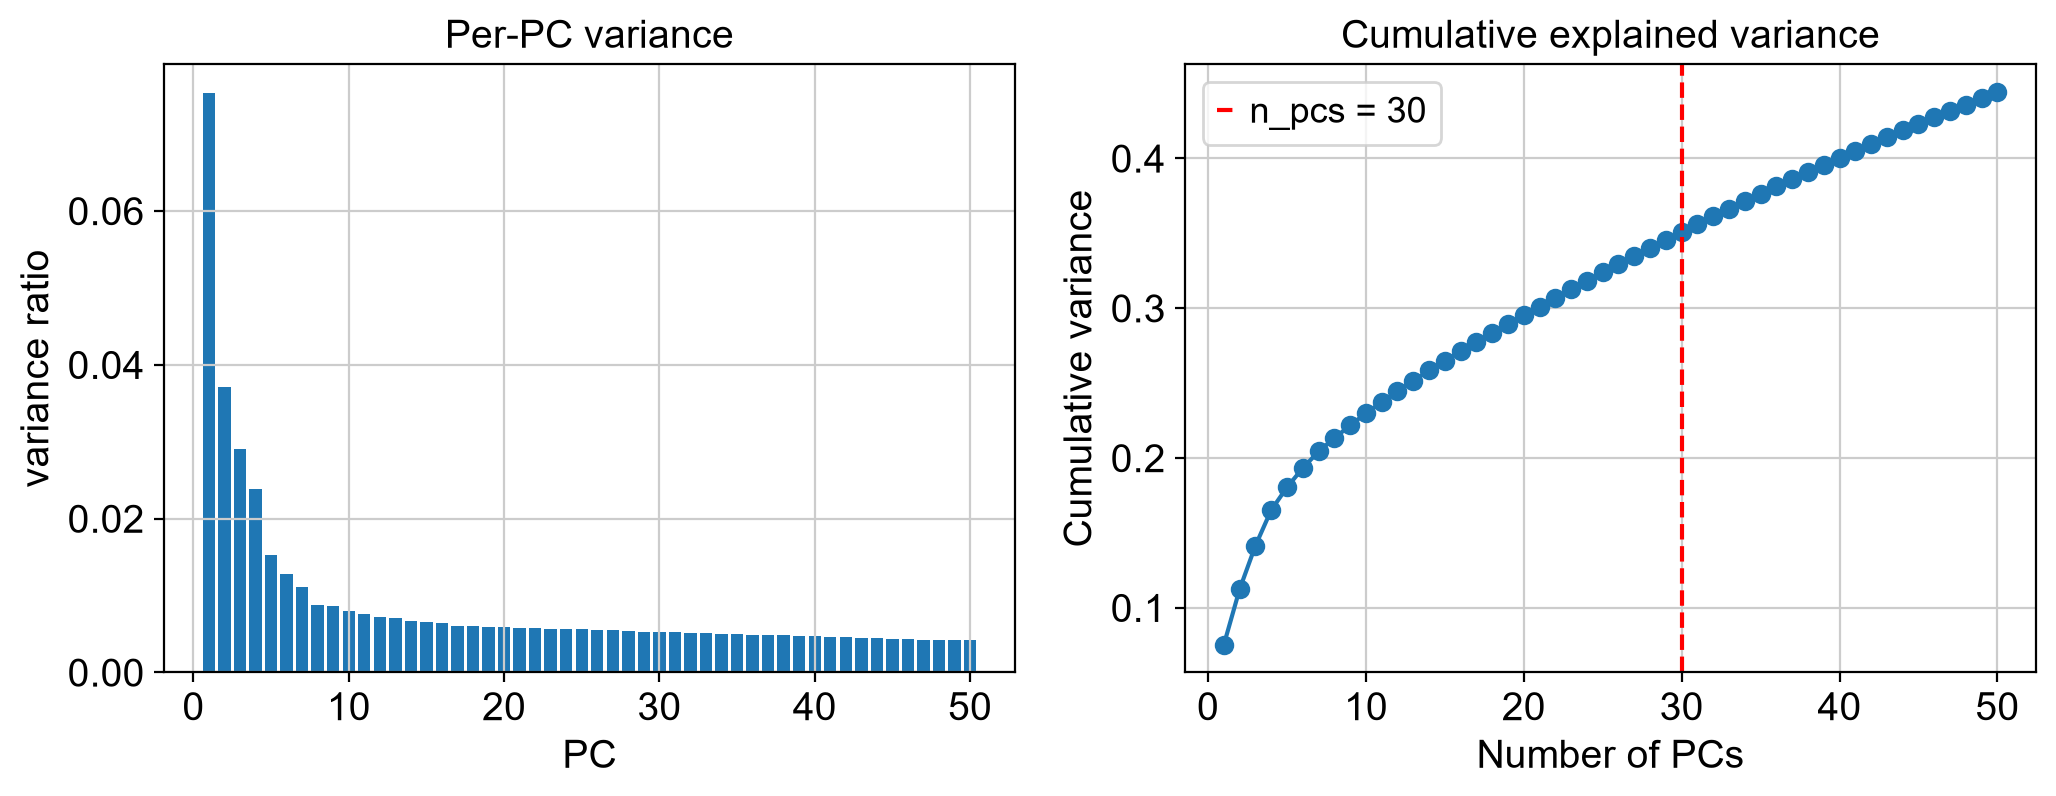

cum var @ 10/20/30/40/50 PCs: [np.float32(0.23), np.float32(0.295), np.float32(0.351), np.float32(0.4), np.float32(0.444)]


In [6]:
vr = adata.uns['pca']['variance_ratio']
cum = np.cumsum(vr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, 51), vr[:50])
axes[0].set_xlabel("PC"); axes[0].set_ylabel("variance ratio"); axes[0].set_title("Per-PC variance")
axes[1].plot(range(1, 51), cum[:50], "o-")
axes[1].axvline(30, color="r", ls="--", label="n_pcs = 30")
axes[1].set_xlabel("Number of PCs"); axes[1].set_ylabel("Cumulative variance")
axes[1].set_title("Cumulative explained variance"); axes[1].legend()
fig.savefig(FIG_DIR / "task3_pca_variance.png", dpi=300, bbox_inches="tight")
plt.show()

print("cum var @ 10/20/30/40/50 PCs:",
      [round(cum[n-1], 3) for n in [10, 20, 30, 40, 50]])


## PCA colored by drug, dose, and replicate

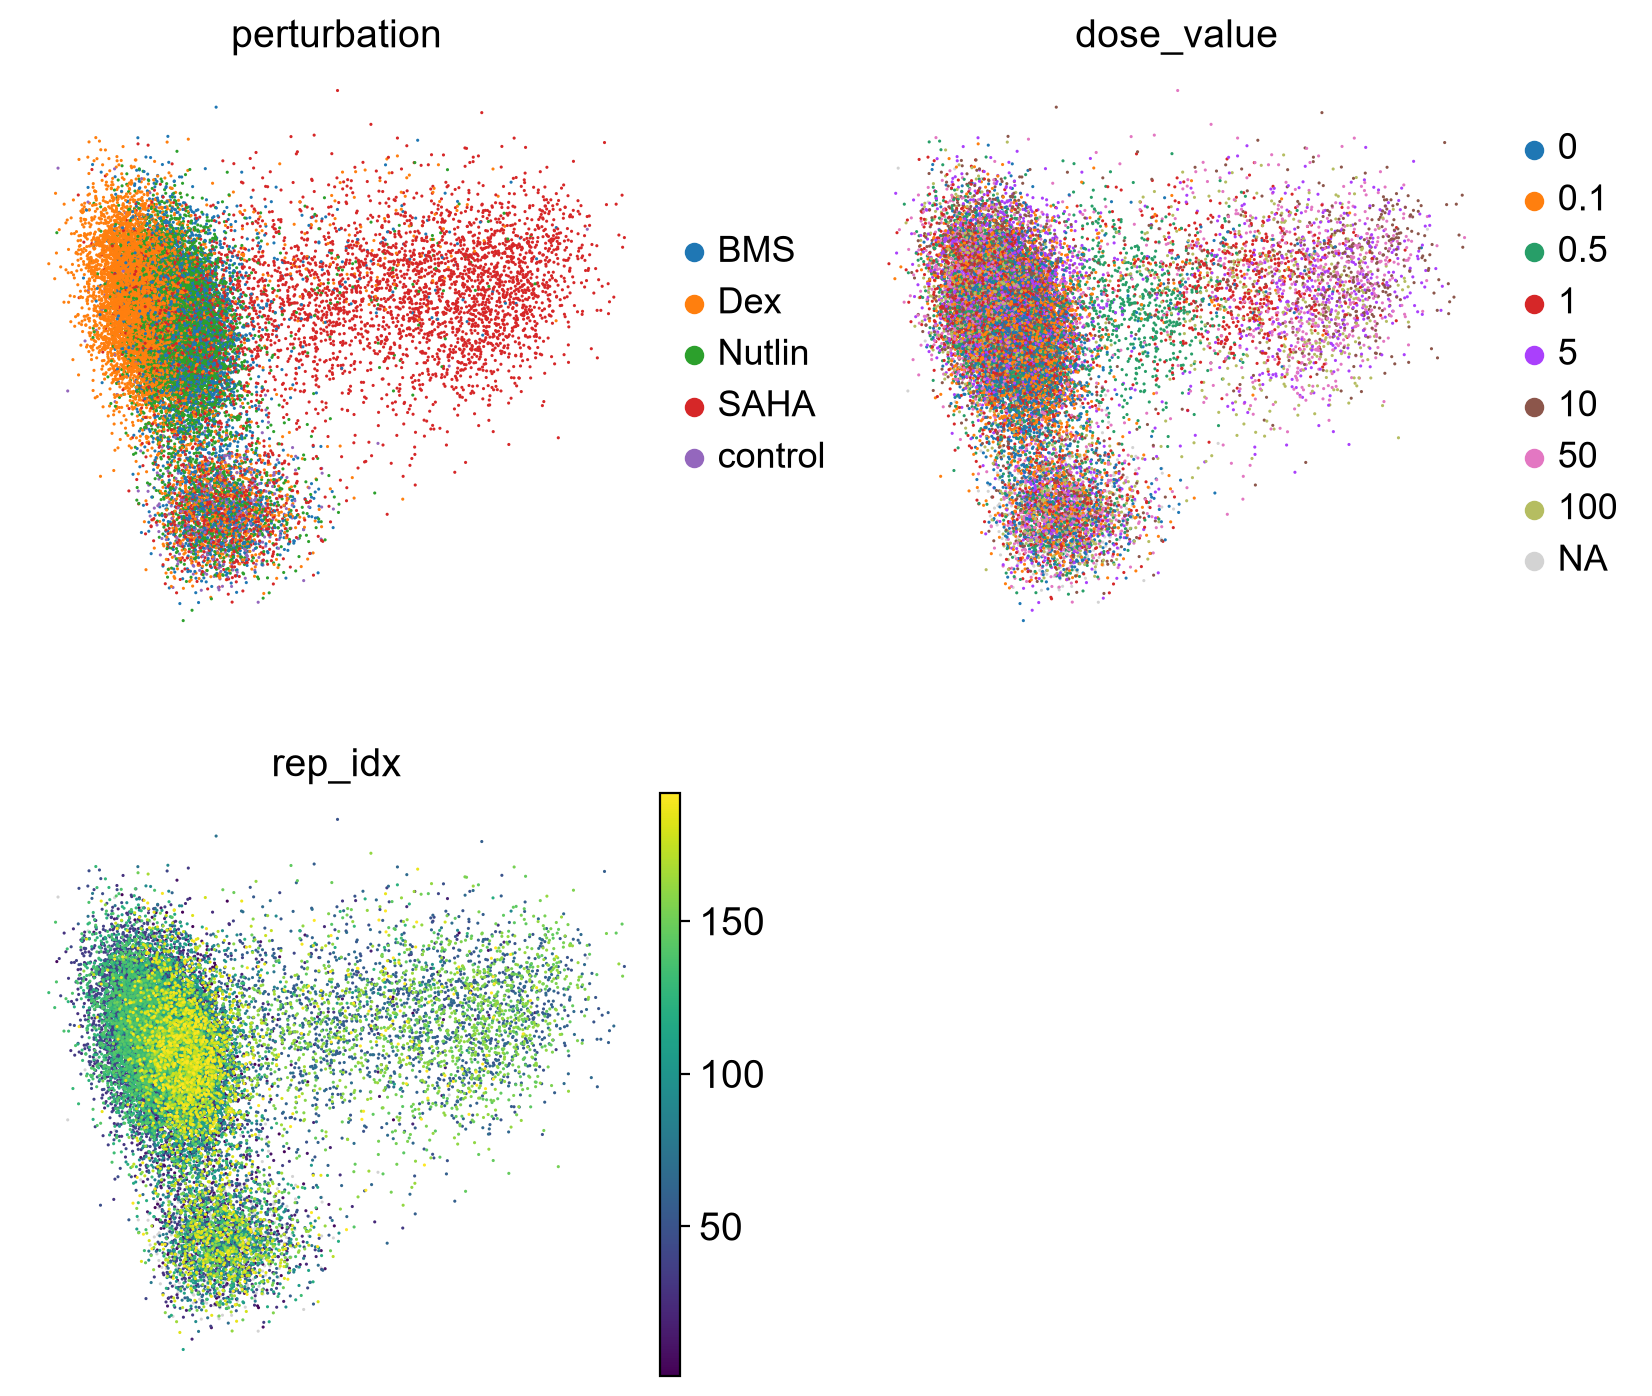

In [7]:
adata.obs['rep_idx'] = adata.obs.groupby(['perturbation', 'dose_value'], observed=True)['well'].transform(
    lambda s: pd.Categorical(s).codes + 1
)

dose_order = ['0', '0.1', '0.5', '1', '5', '10', '50', '100']
adata.obs['dose_value'] = adata.obs['dose_value'].cat.reorder_categories(dose_order)

sc.pl.pca(adata, color=['perturbation', 'dose_value', 'rep_idx'], ncols=2, show=False)
plt.savefig(FIG_DIR / 'task3_pca_drug_dose.png', dpi=300, bbox_inches='tight')
plt.show()


## UMAP (visualization only)

In [8]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)
print("UMAP done:", adata.obsm['X_umap'].shape)


UMAP done: (23628, 2)


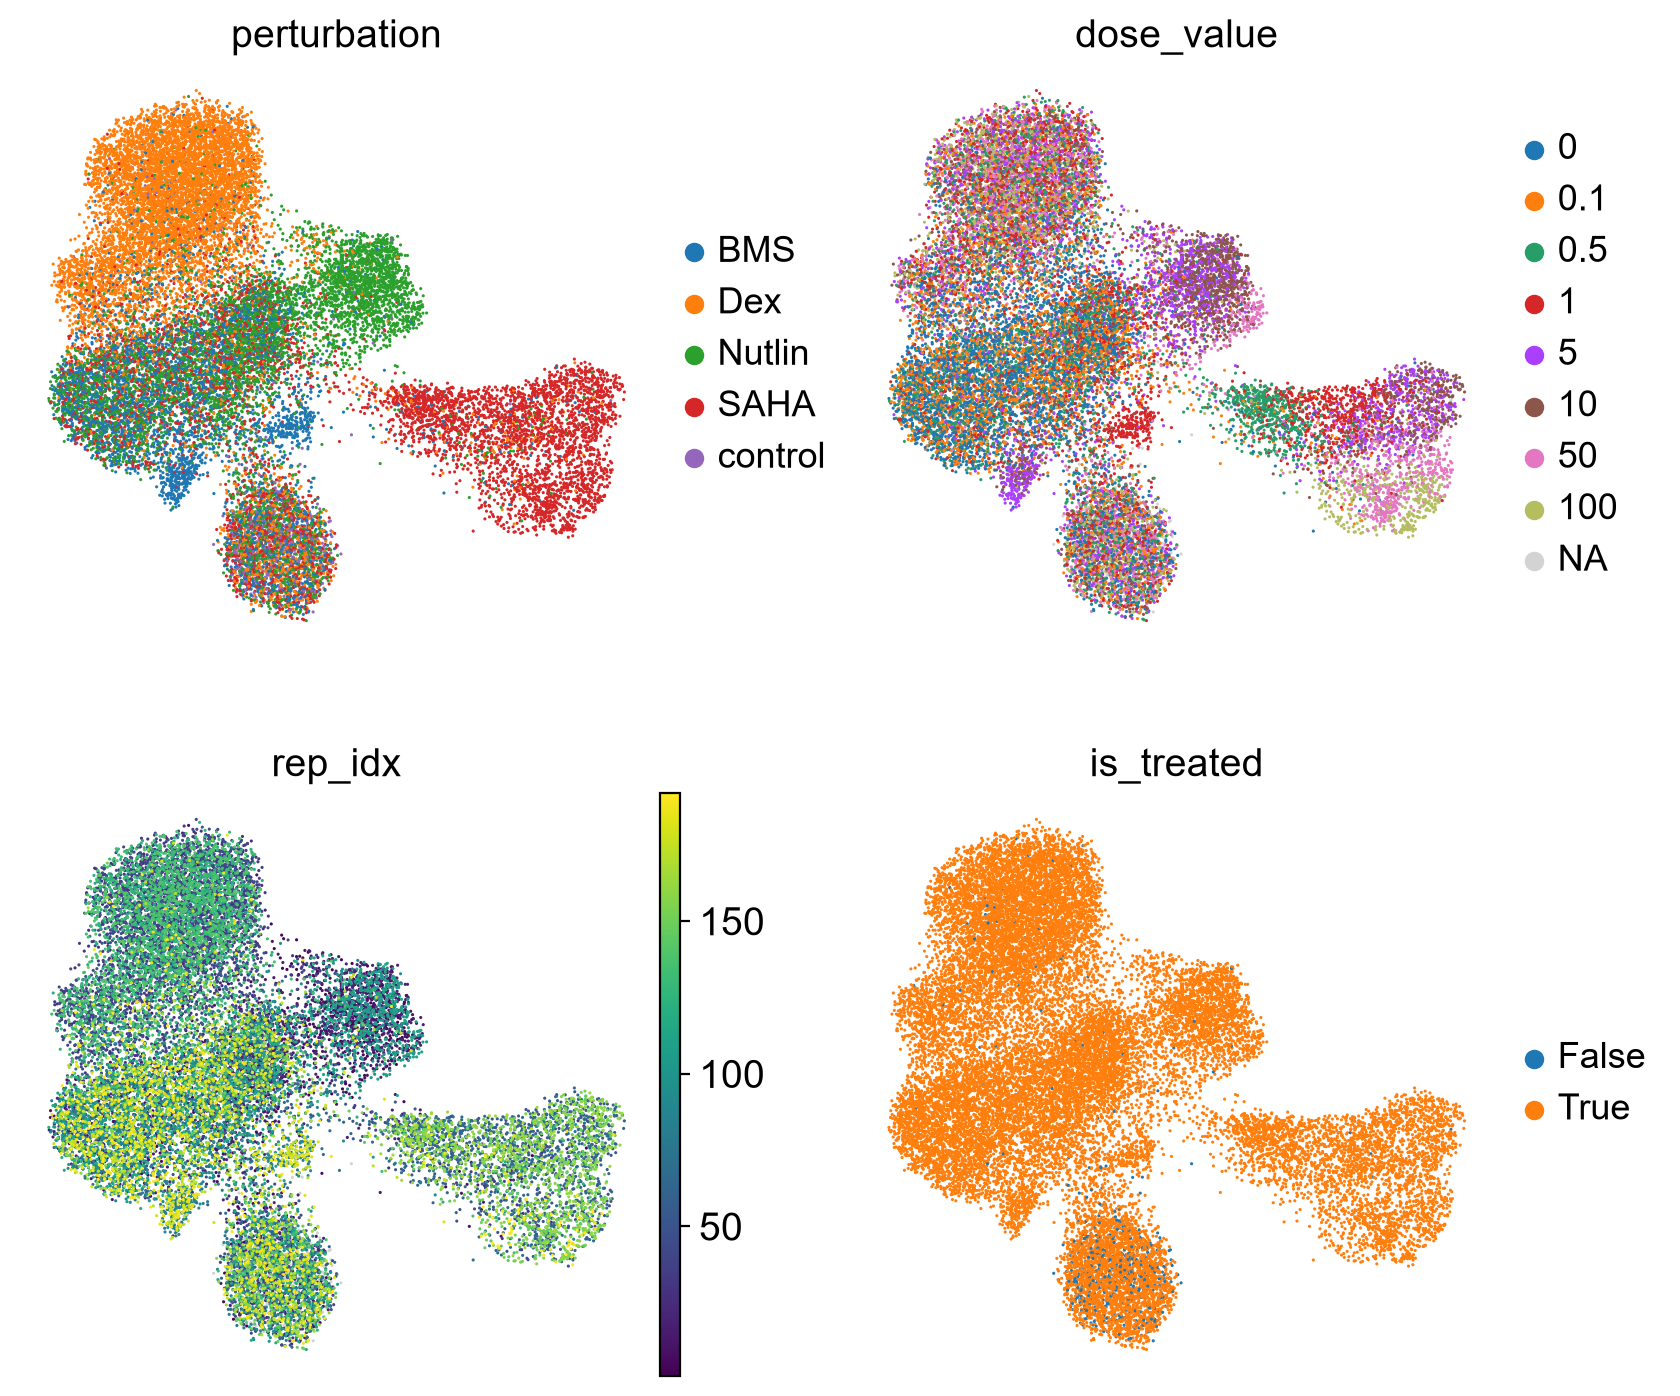

In [9]:
adata.obs['is_treated'] = adata.obs['perturbation'] != 'control'

sc.pl.umap(adata, color=['perturbation', 'dose_value', 'rep_idx', 'is_treated'],
           ncols=2, show=False)
plt.savefig(FIG_DIR / 'task3_umap_global.png', dpi=300, bbox_inches='tight')
plt.show()


## Focus compounds

Mechanistic analysis focuses on Nutlin-3a and vorinostat (SAHA).

In [10]:
print("perturbation values:", adata.obs['perturbation'].unique().tolist())


perturbation values: ['control', 'Dex', 'Nutlin', 'BMS', 'SAHA']


## Dose-dependent UMAP (per drug)

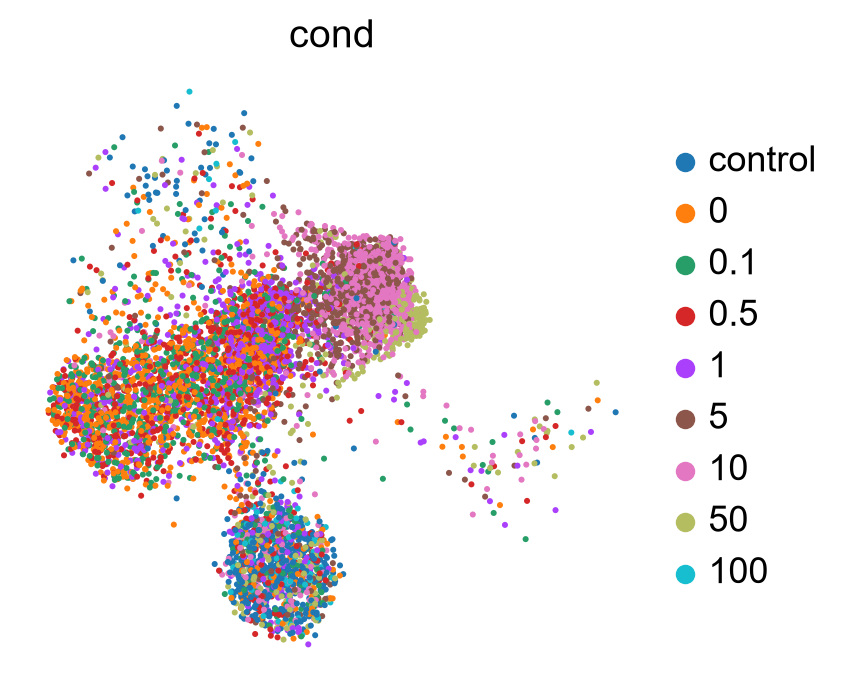

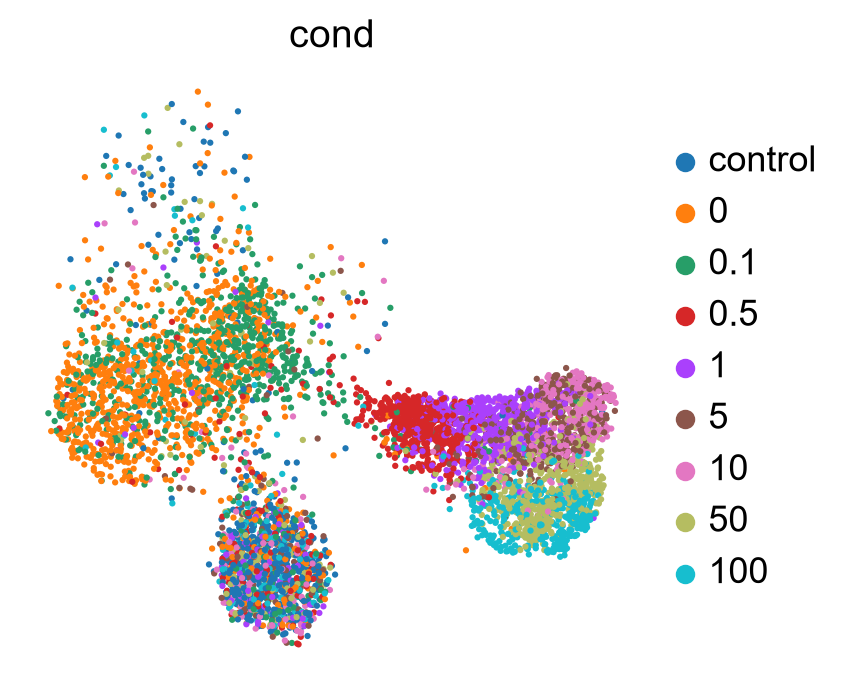

In [11]:
def plot_drug_dose(drug, fname):
    sub = adata[adata.obs['perturbation'].isin([drug, 'control'])].copy()
    sub.obs['cond'] = np.where(
        sub.obs['perturbation'] == 'control', 'control',
        sub.obs['dose_value'].astype(str)
    )
    cond_order = ['control'] + dose_order
    sub.obs['cond'] = sub.obs['cond'].astype('category').cat.reorder_categories(cond_order)
    sc.pl.umap(sub, color='cond', show=False)
    plt.savefig(FIG_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

plot_drug_dose('Nutlin', 'task3_umap_nutlin_dose.png')
plot_drug_dose('SAHA', 'task3_umap_vorinostat_dose.png')


## Baseline choice

The un-hashed control is separated from the hashed dose-0 cells in PCA space by a distance comparable to drug effects, consistent with its lower sequencing depth. Dose-0 centroids (hashed, depth-matched) were therefore used as the baseline for perturbation quantification.

In [12]:
X = adata.obsm['X_pca']
ctrl = (adata.obs['perturbation'] == 'control').values
dose0 = (adata.obs['dose_value'].astype(str) == '0').values
c_ctrl = X[ctrl].mean(axis=0)
c_d0 = X[dose0].mean(axis=0)
print(f"control ({ctrl.sum()} cells) vs dose0 ({dose0.sum()} cells)  PCA distance = {np.linalg.norm(c_ctrl - c_d0):.3f}")

for drug in ['Dex', 'Nutlin', 'BMS', 'SAHA']:
    m0 = (adata.obs['perturbation'] == drug) & (adata.obs['dose_value'].astype(str) == '0')
    m10 = (adata.obs['perturbation'] == drug) & (adata.obs['dose_value'].astype(str) == '10')
    d_drug = np.linalg.norm(X[m10.values].mean(axis=0) - X[m0.values].mean(axis=0))
    print(f"  {drug}: dose0->dose10 drug-effect distance = {d_drug:.3f}")


control (521 cells) vs dose0 (3804 cells)  PCA distance = 4.310
  Dex: dose0->dose10 drug-effect distance = 2.464
  Nutlin: dose0->dose10 drug-effect distance = 4.773
  BMS: dose0->dose10 drug-effect distance = 2.978
  SAHA: dose0->dose10 drug-effect distance = 9.167


## Perturbation magnitude (common dose = 10 µM)

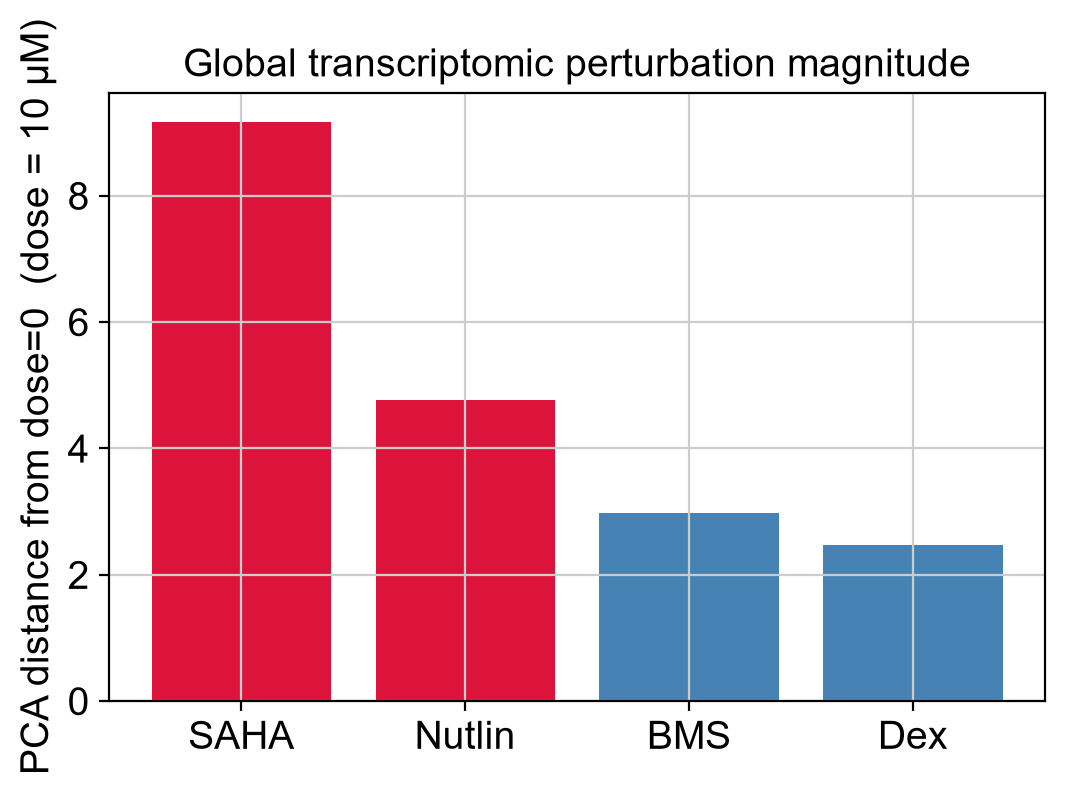

,drug,dist
3,SAHA,9.167180
1,Nutlin,4.772557
2,BMS,2.978120
0,Dex,2.464417


In [13]:
def drug_magnitude(dose='10'):
    rows = []
    X = adata.obsm['X_pca']
    for drug in ['Dex', 'Nutlin', 'BMS', 'SAHA']:
        m0 = (adata.obs['perturbation'] == drug) & (adata.obs['dose_value'].astype(str) == '0')
        md_ = (adata.obs['perturbation'] == drug) & (adata.obs['dose_value'].astype(str) == dose)
        base = X[m0.values].mean(axis=0)
        c = X[md_.values].mean(axis=0)
        rows.append({'drug': drug, 'dist': float(np.linalg.norm(c - base))})
    return pd.DataFrame(rows)

mag = drug_magnitude('10')
mag = mag.sort_values('dist', ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(mag['drug'], mag['dist'], color=['crimson' if d in ['Nutlin','SAHA'] else 'steelblue' for d in mag['drug']])
ax.set_ylabel('PCA distance from dose=0  (dose = 10 µM)')
ax.set_title('Global transcriptomic perturbation magnitude')
fig.savefig(FIG_DIR / 'task3_drug_perturbation_magnitude.png', dpi=300, bbox_inches='tight')
plt.show()
mag


## Perturbation direction (100 µM)

Perturbation direction was compared at the 100 µM high-dose condition.

Drug-response vectors were compared via cosine similarity. High cosine similarity indicates similar global transcriptional direction, not identical pharmacological mechanism.

In [14]:
X = adata.obsm['X_pca']
obs = adata.obs

def drug_vector(drug, dose='100'):
    m0 = (obs['perturbation'] == drug) & (obs['dose_value'].astype(str) == '0')
    md_ = (obs['perturbation'] == drug) & (obs['dose_value'].astype(str) == dose)
    return X[md_.values].mean(axis=0) - X[m0.values].mean(axis=0)

def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

vecs = {d: drug_vector(d, '100') for d in ['Dex', 'Nutlin', 'BMS', 'SAHA']}
print("high dose perturbation vector  magnitude:")
for d, v in vecs.items():
    print(f"  {d}: {np.linalg.norm(v):.3f}")

print("\npairwise cosine similarity (direction):")
drugs = ['Dex', 'Nutlin', 'BMS', 'SAHA']
for i in range(len(drugs)):
    for j in range(i+1, len(drugs)):
        print(f"  {drugs[i]} vs {drugs[j]}: {cosine(vecs[drugs[i]], vecs[drugs[j]]):.3f}")


high dose perturbation vector  magnitude:
  Dex: 2.300
  Nutlin: 4.031
  BMS: 3.984
  SAHA: 7.546

pairwise cosine similarity (direction):
  Dex vs Nutlin: 0.269
  Dex vs BMS: 0.218
  Dex vs SAHA: 0.094
  Nutlin vs BMS: 0.956
  Nutlin vs SAHA: 0.351
  BMS vs SAHA: 0.317


## Dose trajectories (PC1–PC2 centroids)

The pooled dose-0 centroid is shown only as a visual reference; quantitative perturbation vectors use drug-specific dose-0 centroids.

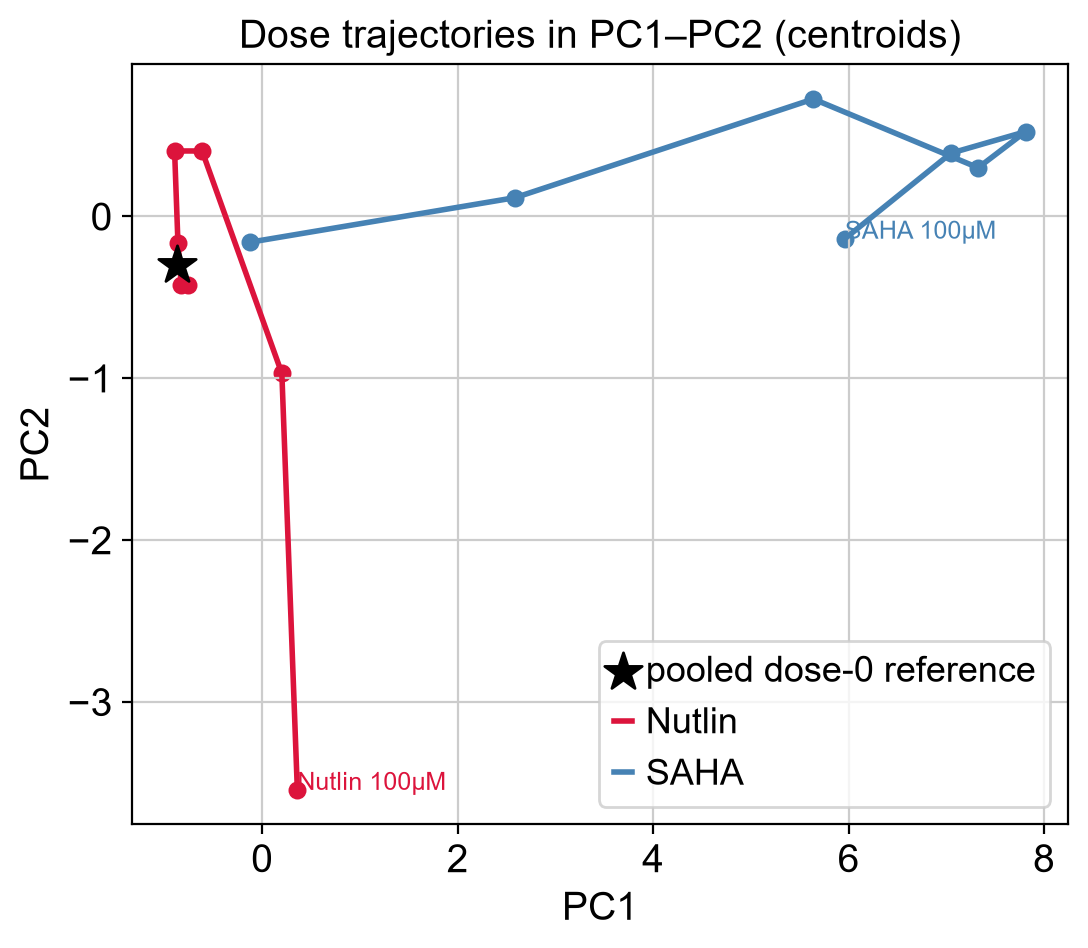

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
X = adata.obsm['X_pca']; obs = adata.obs

m0_all = obs['dose_value'].astype(str) == '0'
ax.scatter(X[m0_all, 0].mean(), X[m0_all, 1].mean(), color='black', marker='*', s=200, label='pooled dose-0 reference', zorder=5)

for drug, color in [('Nutlin', 'crimson'), ('SAHA', 'steelblue')]:
    pts = []
    for dose in ['0.1', '0.5', '1', '5', '10', '50', '100']:
        m = (obs['perturbation'] == drug) & (obs['dose_value'].astype(str) == dose)
        c = X[m.values].mean(axis=0)
        pts.append((c[0], c[1]))
        ax.scatter(c[0], c[1], color=color, s=30)
    pts = np.array(pts)
    ax.plot(pts[:, 0], pts[:, 1], '-', color=color, lw=2, label=drug)
    ax.annotate(drug + ' 100µM', pts[-1], color=color, fontsize=9)

ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Dose trajectories in PC1–PC2 (centroids)')
ax.legend()
fig.savefig(FIG_DIR / 'task3_perturbation_direction.png', dpi=300, bbox_inches='tight')
plt.show()


In [16]:
print("per drug:adjacent-dose vector consistency (cosine)")
for drug in ['Nutlin', 'SAHA', 'Dex', 'BMS']:
    cons = []
    for d1, d2 in [('0.1','1'), ('1','10'), ('10','100')]:
        v1 = drug_vector(drug, d1); v2 = drug_vector(drug, d2)
        cons.append(cosine(v1, v2))
    print(f"  {drug}: low->mid->high cosine = {[round(c,2) for c in cons]}")


per drug:adjacent-dose vector consistency (cosine)
  Nutlin: low->mid->high cosine = [0.67, 0.82, 0.09]
  SAHA: low->mid->high cosine = [0.55, 0.93, 0.86]
  Dex: low->mid->high cosine = [0.97, 0.99, 0.94]
  BMS: low->mid->high cosine = [-0.28, 0.4, -0.2]


## Replicate reproducibility

Within-condition well-to-well dispersion was compared with between-drug distances.

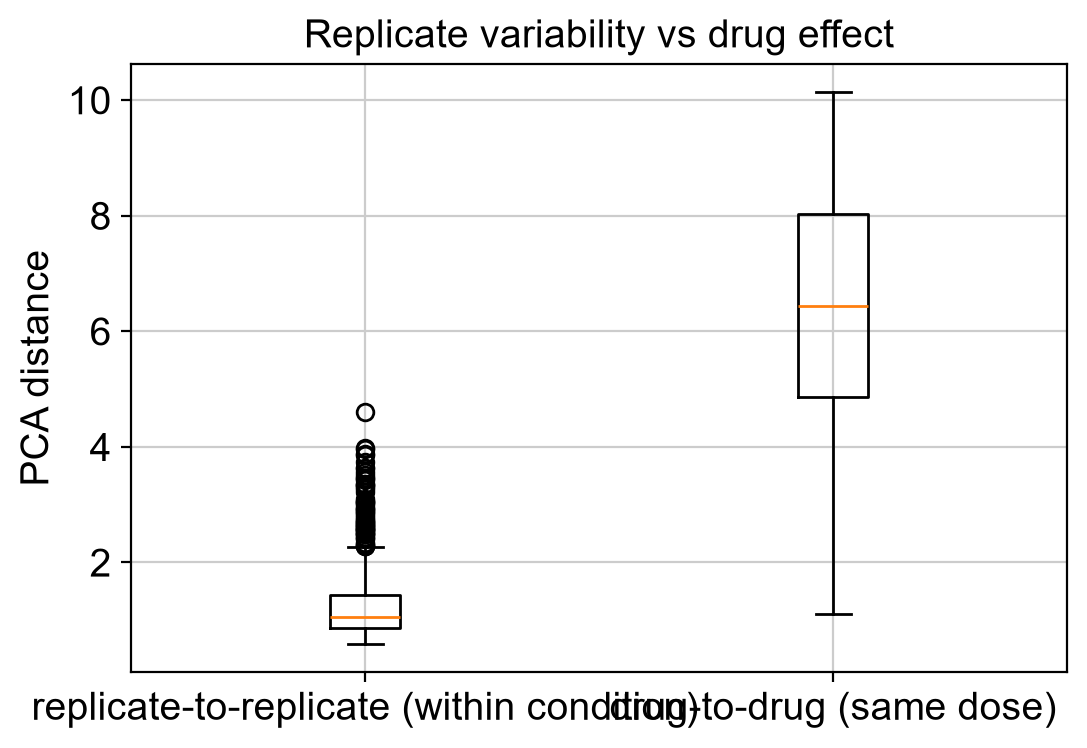

within-condition replicate distance: median=1.048
between-drug distance (same dose):   median=6.441


In [17]:
X = adata.obsm['X_pca']; obs = adata.obs

within_dists = []
for drug in ['Dex', 'Nutlin', 'BMS', 'SAHA']:
    for dv in ['0', '0.1', '0.5', '1', '5', '10', '50', '100']:
        m = (obs['perturbation'] == drug) & (obs['dose_value'].astype(str) == dv)
        if m.sum() < 2:
            continue
        sub_well = obs.loc[m, 'well'].values
        sub_X = X[m.values]
        wells = np.unique(sub_well)
        cents = {w: sub_X[sub_well == w].mean(axis=0) for w in wells}
        for i, w1 in enumerate(wells):
            for w2 in wells[i+1:]:
                within_dists.append(np.linalg.norm(cents[w1] - cents[w2]))
within_dists = np.array(within_dists)

between = []
for dose in ['1', '10', '100']:
    cents = {}
    for drug in ['Dex', 'Nutlin', 'BMS', 'SAHA']:
        m = (obs['perturbation'] == drug) & (obs['dose_value'].astype(str) == dose)
        cents[drug] = X[m.values].mean(axis=0)
    for i, d1 in enumerate(cents):
        for d2 in list(cents)[i+1:]:
            between.append(np.linalg.norm(cents[d1] - cents[d2]))
between = np.array(between)

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([within_dists, between], tick_labels=['replicate-to-replicate (within condition)', 'drug-to-drug (same dose)'])
ax.set_ylabel('PCA distance')
ax.set_title('Replicate variability vs drug effect')
fig.savefig(FIG_DIR / 'task3_replicate_reproducibility.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"within-condition replicate distance: median={np.median(within_dists):.3f}")
print(f"between-drug distance (same dose):   median={np.median(between):.3f}")


## Save

In [18]:
out = DATA_DIR / "processed" / "adata_perturbation_landscape.h5ad"
adata.write_h5ad(out)
print("saved to:", out.relative_to(PROJECT_ROOT))


saved to: data\processed\adata_perturbation_landscape.h5ad


## Key Results

- At 10 µM, perturbation magnitude ranks SAHA (~9.2) > Nutlin-3a (~4.8) > BMS-345541 (~3.0) > dexamethasone (~2.5).
- Nutlin-3a and SAHA follow distinct dose-dependent (and potentially nonlinear) trajectories in PCA space; their perturbation vectors are only moderately aligned (cosine ≈ 0.35), whereas Nutlin-3a and BMS-345541 are nearly collinear (cosine ≈ 0.96).
- Between-drug distances exceed within-condition replicate dispersion by ~6-fold.

## Interpretation

Magnitude and direction capture complementary aspects of drug response. Directional divergence indicates distinct global transcriptional response patterns; pharmacological mechanism requires gene- and pathway-level interpretation (Task 4).

## Limitations

Single cell line (A549); perturbation quantified at the condition level; UMAP is visualization, not a quantitative distance.

## Summary

This notebook characterizes observed perturbations. Predictive modeling is addressed in Task 5.